In [ ]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget

In [17]:
project_name = "syn"
condition = "shape"
data = "biased_00"
switch_epoch = 0

checkpoint_epoch=0

n_samples = 32
show_results_fusion = False
fusion_attr_weight = 1.0
noise = 0.0

project_name = "syn"
experiment_name = get_experiment_name(condition, data, switch_epoch)


training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
samples = get_data_samples(data_module, n_samples, split ='train')

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/shape_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/shape_biased_00/checkpoints/last.ckpt


In [18]:
unimodal_latents = global_workspace.encode_domains(samples)
gw_latents = global_workspace.encode(unimodal_latents)

unimodal_decoded = global_workspace.decode(gw_latents[frozenset({'attr', 'v_latents'})])

a_from_v_decoded = split_softmax_category_attributes(unimodal_decoded["v_latents"]["attr"])
v_from_a_decoded = unimodal_decoded["attr"]["v_latents"]
demi_cycle_attr = unimodal_decoded["attr"]["attr"]
demi_cycle_v_latents = unimodal_decoded["v_latents"]["v_latents"]

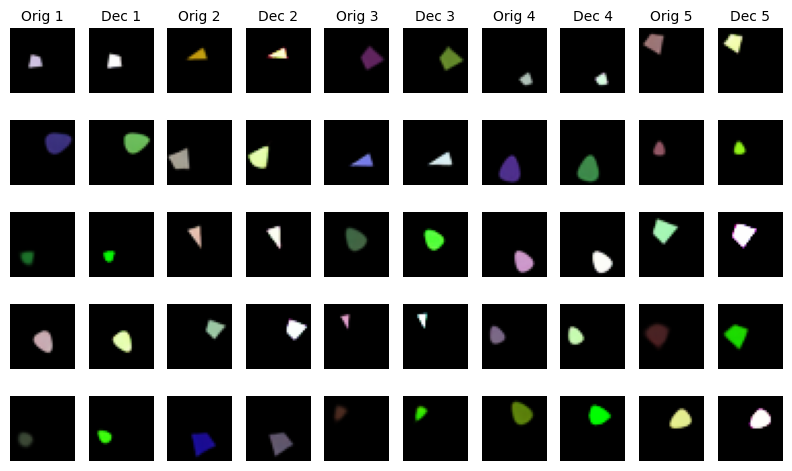

In [19]:
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])    

original_v_latents = samples[frozenset({'v_latents', 'attr'})]['v_latents']
original_images = visual_module.decode_images(original_v_latents).detach().cpu()
demi_cycle_images = visual_module.decode_images(demi_cycle_v_latents).detach().cpu()

fig = plot_img_comparison_triple_stripes(original_images, demi_cycle_images)
display(fig)